In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

try:
    import cmocean
    cmap = cmocean.cm.tempo
except ImportError:
    cmap = "viridis"


path_event = "/work/uc1275/u301827/02_MSE/full_midlatitude/TDAILYMAX/event_at_tdailymax_merged_1940_2024.nc"
path_txx   = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

outfile = "txx_t500xx_overlap_3d_7d_midlatitude_percent.png"

ds_event = xr.open_dataset(path_event)
ds_txx   = xr.open_dataset(path_txx)

ds_event, ds_txx = xr.align(ds_event, ds_txx, join="exact")


def yyyymmdd_to_datetime64(da):
    vals = da.values
    mask = np.isfinite(vals) & (vals > 0)

    out = np.full(vals.shape, np.datetime64("NaT"), dtype="datetime64[D]")

    flat = vals[mask].astype("int64")
    year = flat // 10000
    month = (flat // 100) % 100
    day = flat % 100

    out[mask] = pd.to_datetime(
        {"year": year, "month": month, "day": day},
        errors="coerce",
    ).values.astype("datetime64[D]")

    return xr.DataArray(
        out,
        coords=da.coords,
        dims=da.dims,
        name=da.name + "_date",
    )


event_date = yyyymmdd_to_datetime64(ds_event["event_yyyymmdd"])
txx_date   = yyyymmdd_to_datetime64(ds_txx["txx_yyyymmdd"])

days_event_before_txx = (txx_date - event_date) / np.timedelta64(1, "D")

valid = event_date.notnull() & txx_date.notnull()
valid_years_per_gridcell = valid.sum(dim="year")


def overlap_percent(max_days_before):
    overlap = (
        (days_event_before_txx >= 0)
        & (days_event_before_txx <= max_days_before)
        & valid
    )

    overlap_years = overlap.sum(dim="year")

    # Percent of valid years at each grid cell
    return 100.0 * overlap_years / valid_years_per_gridcell


overlap_3d_pct = overlap_percent(3)
overlap_5d_pct = overlap_percent(5)
overlap_7d_pct = overlap_percent(7)

lat_min = float(ds_event["lat"].min())
lat_max = float(ds_event["lat"].max())

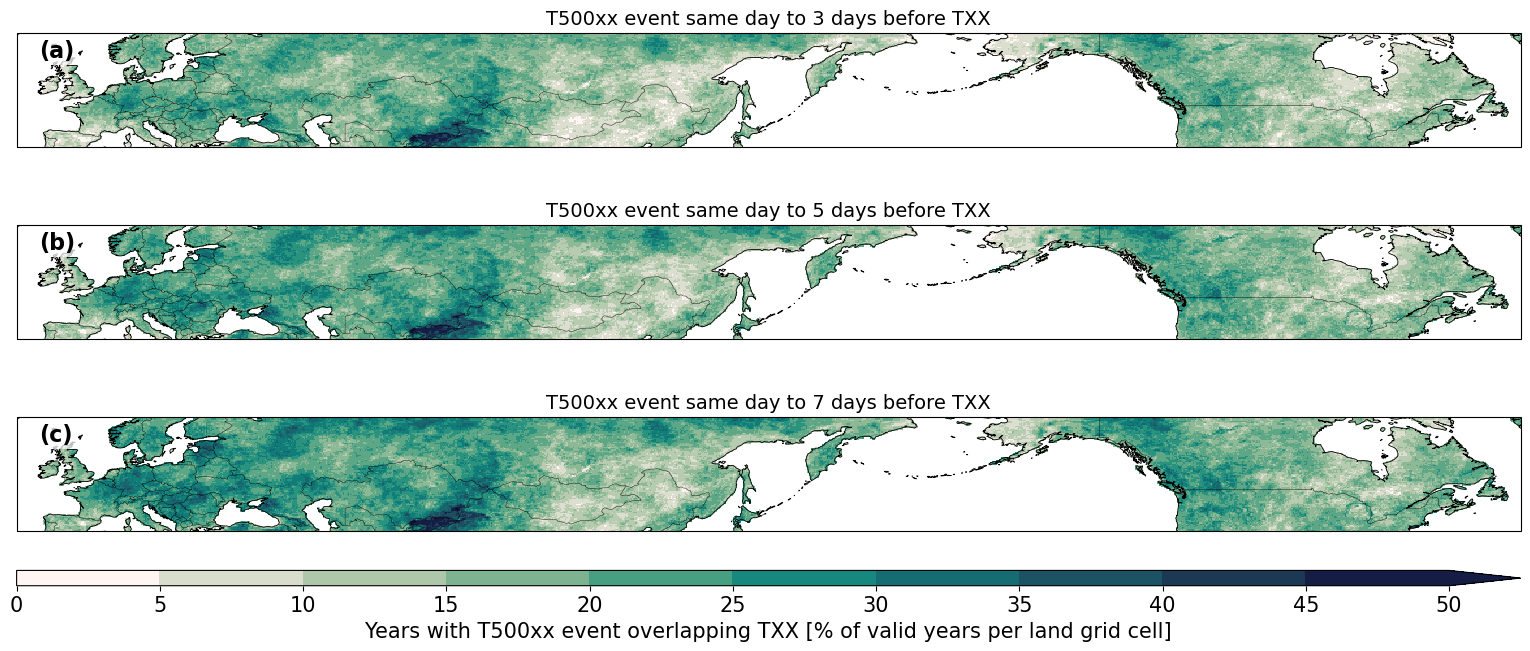

In [2]:
import regionmask
from matplotlib.colors import BoundaryNorm

# If not computed yet:
# overlap_5d_pct = overlap_percent(5)

# ============================================================
# Land mask
# ============================================================
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110

land_mask = land.mask(
    overlap_3d_pct["lon"],
    overlap_3d_pct["lat"],
) == 0

overlap_3d_pct_land = overlap_3d_pct.where(land_mask)
overlap_5d_pct_land = overlap_5d_pct.where(land_mask)
overlap_7d_pct_land = overlap_7d_pct.where(land_mask)

# ============================================================
# Plot stacked maps
# ============================================================
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 6.8))

gs = gridspec.GridSpec(
    nrows=4,
    ncols=1,
    height_ratios=[1, 1, 1, 0.08],
    hspace=0.005,
)

ax1 = fig.add_subplot(gs[0], projection=proj)
ax2 = fig.add_subplot(gs[1], projection=proj)
ax3 = fig.add_subplot(gs[2], projection=proj)
cax = fig.add_subplot(gs[3])

axes = [ax1, ax2, ax3]

levels = np.arange(0, 51, 5)
ticks = levels

norm = BoundaryNorm(levels, ncolors=cmap.N)

plot_data = [
    (overlap_3d_pct_land, "(a)", "T500xx event same day to 3 days before TXX"),
    (overlap_5d_pct_land, "(b)", "T500xx event same day to 5 days before TXX"),
    (overlap_7d_pct_land, "(c)", "T500xx event same day to 7 days before TXX"),
]

for ax, (da, panel_label, title) in zip(axes, plot_data):

    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, alpha=0.10)

    im = da.plot(
        ax=ax,
        transform=data_crs,
        x="lon",
        y="lat",
        cmap=cmap,
        levels=levels,
        add_colorbar=False,
        extend="max",
    )

    ax.set_extent([-15, 310, lat_min, lat_max], crs=data_crs)

    ax.text(
        0.015, 0.94, panel_label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2),
    )

    ax.set_title(title, fontsize=14)

# ============================================================
# Colorbar
# ============================================================
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation="horizontal",
    ticks=ticks,
    extend="max",
)

cbar.set_label(
    "Years with T500xx event overlapping TXX [% of valid years per land grid cell]",
    fontsize=15,
)

cbar.ax.tick_params(labelsize=15)
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))

plt.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.95,
    bottom=0.08,
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()